# 04 · squeeze_bull top anatomy (exploratory, stage A)

**The user's question.** *"What if we study what happened after squeeze bull got an entry. Assumption is that there is
spike up, like we just had. What happened just before the price action reversed? How does it look like and how does the
all previous similar events look like? Maybe there is no reverse at all, but something else that tells it's time to
exit?"*

Protocol: [PROTOCOL_TOP_ANATOMY.md](PROTOCOL_TOP_ANATOMY.md) (with Amendment A1). Write-up:
[findings_top_anatomy.md](findings_top_anatomy.md). **Exploratory:** every number here describes one discovery set of
122 fires; nothing is decided. Any exit idea is tested only on holdout data (ETH flushes, BTC non-bull flushes, live
fires) in a separate, pre-registered stage B.

The one trap: lining paths up on their highest point always shows a rise into it and a fall after it. The comparison
that matters is **the final top against the same fire's earlier new highs that paused and then kept going**, measured
with data known at that minute.

In [1]:
import json, sys
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from IPython.display import display

STUDY = Path.cwd()
assert (STUDY / "PROTOCOL_TOP_ANATOMY.md").exists(), "execute from studies/notebooks/exit_policy_2026_09"
sys.path.insert(0, str(STUDY)); sys.path.insert(0, str(STUDY.parent / "orb_study"))
import anatomy_lib as A, micro_lib as ML
from review_plots import AXIS, INK2, MUTED, NEUTRAL, SERIES, style, zero_line
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
RES = A.RESULTS
MA, MA1 = (json.loads((RES / f).read_text()) for f in ("manifest_A.json", "manifest_A1.json"))
changed_A = [f for f, h in MA["files"].items() if ML.sha256(STUDY / f) != h]
changed_A1 = [f for f, h in MA1["files"].items() if ML.sha256(STUDY / f) != h]
print("stage A run", MA["created_utc"], "| files changed since:", changed_A, "(the protocol gained Amendment A1)")
print("amendment A1", MA1["created_utc"], "| files changed since:", changed_A1)
SUM, TVF, REP, SMAP, DC, CASE, PP = (json.loads((RES / f).read_text()) for f in
    ("summary.json", "top_vs_false.json", "repair.json", "state_map.json", "data_checks.json", "case_SJ-4250.json", "profiles_paired.json"))
SH = pd.read_csv(RES / "shapes.csv")

stage A run 2026-09-15T16:31:29+00:00 | files changed since: ['PROTOCOL_TOP_ANATOMY.md'] (the protocol gained Amendment A1)
amendment A1 2026-09-15T16:34:59+00:00 | files changed since: []


## 1. The run is reproducible

Shapes, the top-versus-false-top table, the repair table and the state map are computed again from the library and
the checksum-verified data, then compared with the saved files.

In [2]:
mkt = A.load_market()
fires = A.load_fires(mkt)
sh = A.shapes(mkt, fires)
_, tvf = A.top_vs_false(mkt, sh)
_, rep = A.repair(mkt, sh)
_, smap = A.state_map(mkt, fires)
same_shapes = sh[["fid", "shape", "S", "T", "C"]].astype(str).equals(SH[["fid", "shape", "S", "T", "C"]].astype(str))
close = lambda a, b: json.dumps(a, sort_keys=True, default=str) == json.dumps(b, sort_keys=True, default=str)
print("shapes identical:", same_shapes, "| top vs false:", close(json.loads(json.dumps(tvf)), TVF),
      "| repair:", close(json.loads(json.dumps(rep)), REP), "| state map:", close(json.loads(json.dumps(smap)), SMAP))

shapes identical: True | top vs false: True | repair: True | state map: True


## 2. The case: SJ-4250

Entry 2026-09-11 18:00 at 77,493.9. The flush had taken price down 2.2 % from 79,208 over four hours. On the
convention the strategy was validated on (open interest at each bar's close), the open-interest drop was −1.8 %, short
of the −2 % trigger; section 8 explains why the bot fired.

- **Before the time stop.** Price sagged for almost three days, and the entry minute stayed its high. Open interest
  was fully back by 09-13 13:34, before the time stop closed the trade on 09-13 17:00.
- **The spike.** Price crossed +2 % on 09-14 18:19, got back to where the flush started at 18:46, paused once at 18:48,
  topped at 20:23 at +2.68 %, and fell 2 % by 09-15 00:20.
- **Positioning during the spike.** Open interest peaked at 2.0× the flushed amount at 06:15 on 09-14 and fell during
  the spike, to 0.5 at the top. The all-account long/short ratio went from +13 % to −20 % since entry: accounts sold into
  the rise. After the top both reversed.
- **Where it went.** Price reached 75,697 (−2.3 % from entry) on 09-15.

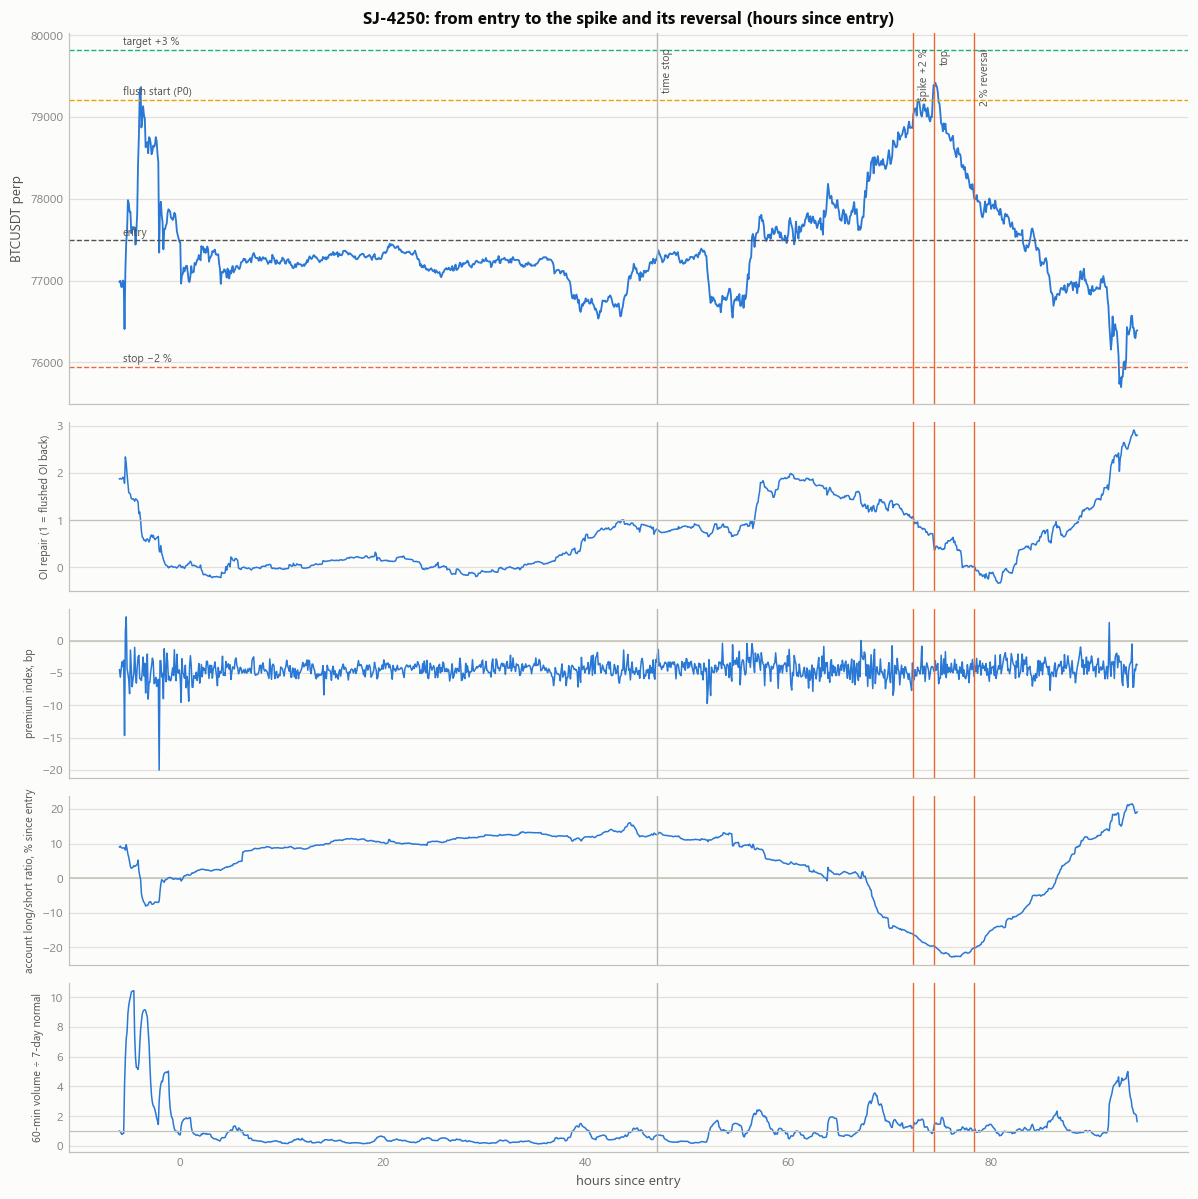

,SJ-4250
entry_utc,2026-09-11T18:00:00+00:00
time_stop_utc,2026-09-13T17:00:00+00:00
spike_start_utc,2026-09-14T18:19:00+00:00
top_utc,2026-09-14T20:23:00+00:00
reversal_utc,2026-09-15T00:20:00+00:00
top_price,79570.9
top_runup_pct,2.680211
PR_at_top,1.144741
OR_at_top,0.511489
first_PR_ge_1_utc,2026-09-14T18:46:00+00:00


In [3]:
cf = pd.read_csv(RES / "case_SJ-4250_features.csv.gz")
cf = cf[cf["rel_min"] >= -6 * 60]
h = cf["rel_min"] / 60
E = CASE["fire"]["entry"]; P0 = CASE["fire"]["P0"]
marks = {"time stop": (A.CASE_EXIT_TS - CASE["fire"]["entry_ts"]) / 3600, "spike +2 %": CASE["shape"]["S"] / 60,
         "top": CASE["shape"]["T"] / 60, "2 % reversal": CASE["shape"]["C"] / 60}
fig, axes = plt.subplots(5, 1, figsize=(11, 11), sharex=True, gridspec_kw={"height_ratios": [2.2, 1, 1, 1, 1]})
ax = axes[0]
ax.plot(h, cf["close"], color=SERIES[0], linewidth=1.2)
for level, lab, colour in ((E * 1.03, "target +3 %", SERIES[2]), (P0, "flush start (P0)", SERIES[3]), (E, "entry", INK2), (E * 0.98, "stop −2 %", SERIES[1])):
    ax.axhline(level, color=colour, linewidth=0.9, linestyle="--")
    ax.annotate(lab, xy=(h.iloc[0], level), xytext=(2, 3), textcoords="offset points", fontsize=7, color=INK2)
ax.set_ylabel("BTCUSDT perp")
ax.set_title("SJ-4250: from entry to the spike and its reversal (hours since entry)")
panels = [("OR", "OI repair (1 = flushed OI back)"), ("premium_bp", "premium index, bp"),
          ("account_lsr_chg_pct", "account long/short ratio, % since entry"), ("volume_ratio_60", "60-min volume ÷ 7-day normal")]
for ax, (col, lab) in zip(axes[1:], panels):
    ax.plot(h, cf[col], color=SERIES[0], linewidth=1.0)
    ax.set_ylabel(lab, fontsize=7)
for ax in axes:
    style(ax)
    for name, x in marks.items():
        ax.axvline(x, color=NEUTRAL if name == "time stop" else SERIES[1], linewidth=0.9)
for name, x in marks.items():
    axes[0].annotate(name, xy=(x, axes[0].get_ylim()[1]), xytext=(3, -10), textcoords="offset points", fontsize=7, color=INK2, rotation=90, va="top")
axes[1].axhline(1, color=AXIS, linewidth=0.8); zero_line(axes[2]); zero_line(axes[3]); axes[4].axhline(1, color=AXIS, linewidth=0.8)
axes[-1].set_xlabel("hours since entry")
plt.tight_layout(); plt.show()
pd.Series({k: CASE[k] for k in ("entry_utc", "time_stop_utc", "spike_start_utc", "top_utc", "reversal_utc", "top_price",
                                "top_runup_pct", "PR_at_top", "OR_at_top", "first_PR_ge_1_utc", "first_OR_ge_1_utc",
                                "P0_minus_entry_pct", "oi_flush_pct_archive", "panel_end_utc")}).to_frame("SJ-4250")

## 3. All 122 fires: how the bounces went

**Shapes.** In the 7 days after entry, 103 fires spiked at least +2 % and then fell 2 % from their peak. 16 never
reached +2 %; 3 reached it and did not fall 2 %.

**Timing.** The spike came a median 18 h after entry. Once price crossed +2 %, the top came fast: a median 2 h later,
and within 12 minutes for a quarter of them. The top was at a median +3.2 %, 28 h after entry. 35 of the 103 tops came
after 48 h, where the time stop had already closed the trade. After the top, price fell a median 3.2 % within 24 h.

,fires
shape,
spike_reversal,103
no_spike,16
spike_no_reversal,3


,count,mean,std,min,25%,50%,75%,max
hours_to_spike,103.0,32.17,34.75,0.30,6.33,17.98,44.34,157.35
hours_spike_to_top,103.0,8.88,15.89,0.00,0.20,2.03,11.19,84.73
hours_to_top,103.0,41.05,35.97,0.37,15.42,28.45,61.28,157.37
top_runup_pct,103.0,4.09,2.31,2.02,2.50,3.21,4.91,13.20
fall_24h_after_top_pct,103.0,-3.50,1.28,-7.83,-4.20,-3.24,-2.46,-2.02
max_pct_7d,103.0,7.35,4.84,2.03,3.86,5.90,9.44,26.13


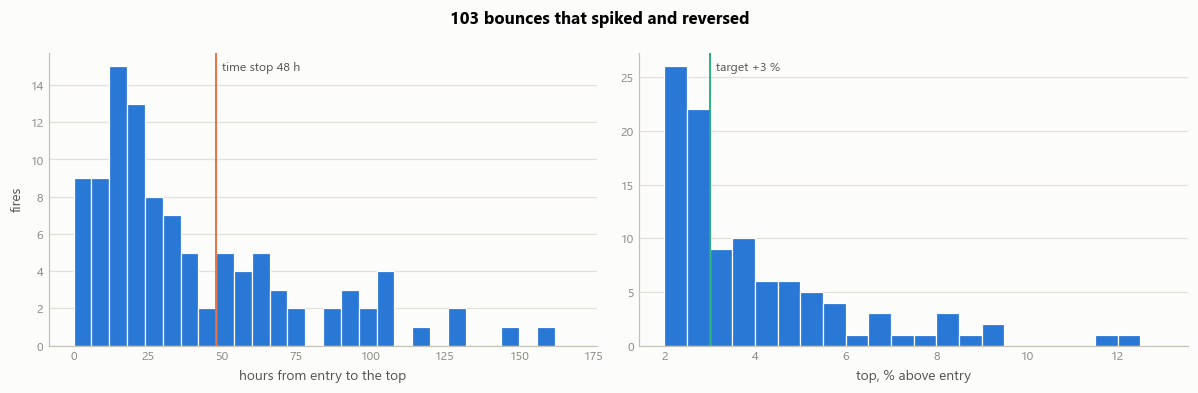

In [4]:
sr = SH[SH["shape"] == "spike_reversal"]
display(SH["shape"].value_counts().to_frame("fires"))
display(sr[["hours_to_spike", "hours_spike_to_top", "hours_to_top", "top_runup_pct", "fall_24h_after_top_pct", "max_pct_7d"]]
        .describe(percentiles=[0.25, 0.5, 0.75]).T.round(2))
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].hist(sr["hours_to_top"], bins=np.arange(0, 170, 6), color=SERIES[0], edgecolor="white", linewidth=0.8)
axes[0].axvline(48, color=SERIES[1], linewidth=1.2)
axes[0].annotate("time stop 48 h", xy=(48, axes[0].get_ylim()[1]), xytext=(4, -12), textcoords="offset points", fontsize=8, color=INK2)
axes[0].set_xlabel("hours from entry to the top"); axes[0].set_ylabel("fires"); style(axes[0])
axes[1].hist(sr["top_runup_pct"], bins=np.arange(2, 13.5, 0.5), color=SERIES[0], edgecolor="white", linewidth=0.8)
axes[1].axvline(3, color=SERIES[2], linewidth=1.2)
axes[1].annotate("target +3 %", xy=(3, axes[1].get_ylim()[1]), xytext=(4, -12), textcoords="offset points", fontsize=8, color=INK2)
axes[1].set_xlabel("top, % above entry"); style(axes[1])
fig.suptitle("103 bounces that spiked and reversed", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## 4. Every top, aligned

Price in % of the top, from 24 h before to 24 h after. The thick line is the median. Small multiples below show every
fire; the dashed line is the entry price, the orange tick is where the 48 h time stop fell.

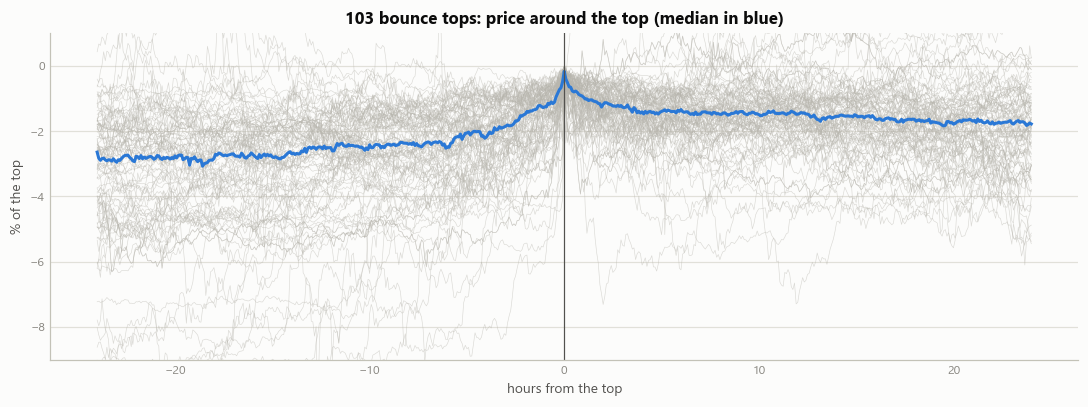

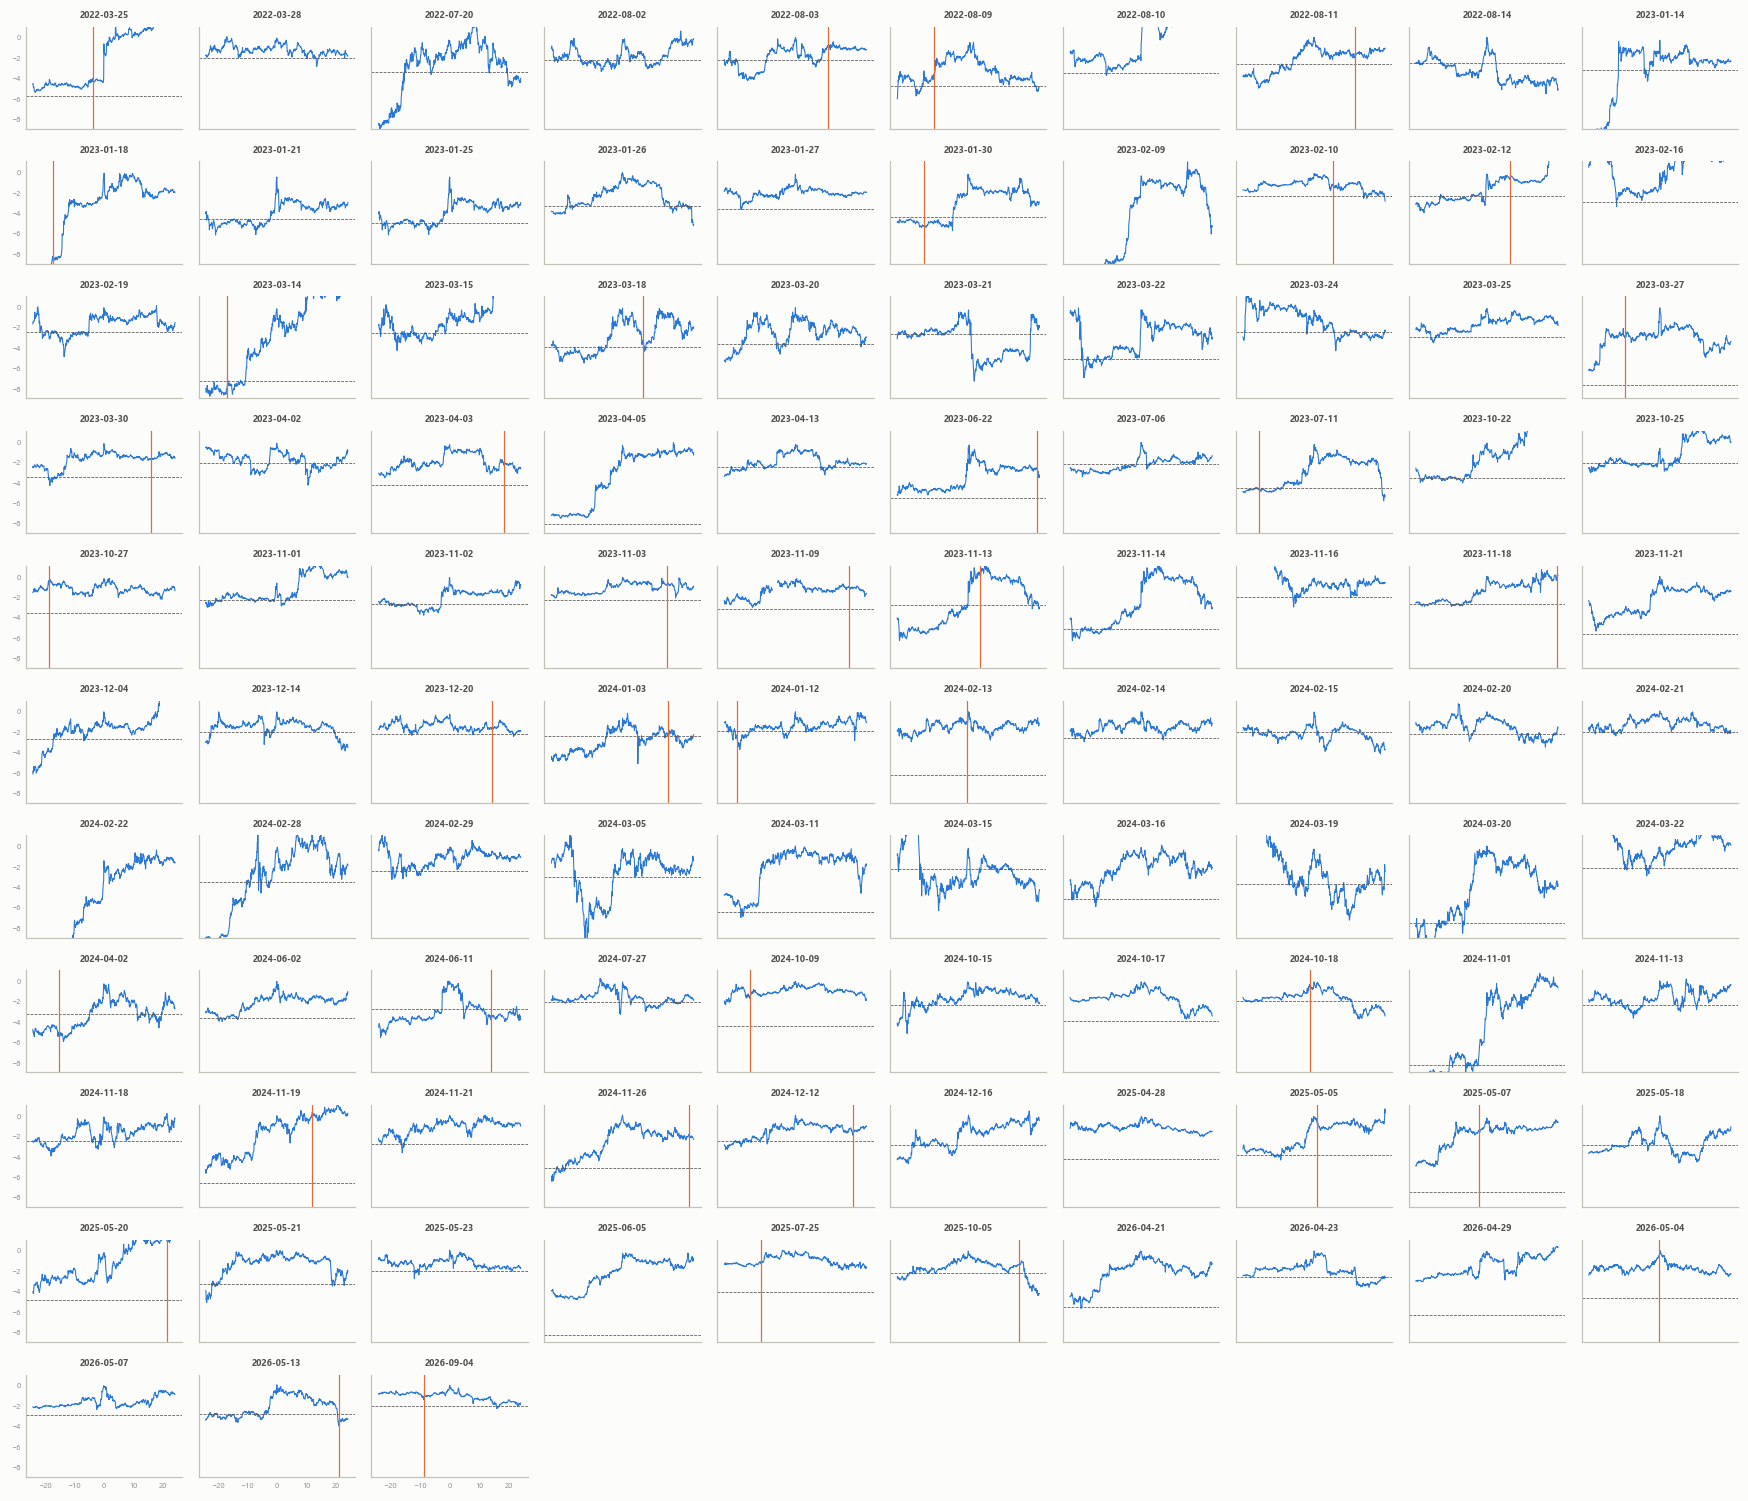

In [5]:
G = pd.read_csv(RES / "gallery.csv")
M = np.load(RES / "gallery.npz")["close_pct_of_top"]
lags_h = (G["lags_from"].iat[0] + np.arange(M.shape[1]) * G["lag_step"].iat[0]) / 60
fig, ax = plt.subplots(figsize=(10, 3.8))
for row in M:
    ax.plot(lags_h, row, color=NEUTRAL, linewidth=0.4, alpha=0.5)
ax.plot(lags_h, np.nanmedian(M, axis=0), color=SERIES[0], linewidth=2)
ax.axvline(0, color=INK2, linewidth=0.8); style(ax); ax.set_ylim(-9, 1)
ax.set_xlabel("hours from the top"); ax.set_ylabel("% of the top")
ax.set_title("103 bounce tops: price around the top (median in blue)")
plt.tight_layout(); plt.show()
cols = 10
rows = int(np.ceil(len(G) / cols))
fig, axes = plt.subplots(rows, cols, figsize=(16, 1.25 * rows), sharex=True, sharey=True)
for k, ax in enumerate(axes.flat):
    if k >= len(G):
        ax.axis("off"); continue
    g = G.iloc[k]
    ax.plot(lags_h, M[k], color=SERIES[0], linewidth=0.7)
    ax.axhline(g["entry_pct_of_top"], color=INK2, linewidth=0.5, linestyle="--")
    ts_h = g["time_stop_rel_min"] / 60
    if -24 <= ts_h <= 24:
        ax.axvline(ts_h, color=SERIES[1], linewidth=0.8)
    ax.set_title(pd.Timestamp(int(g["fid"].split(":")[1]), unit="s").strftime("%Y-%m-%d"), fontsize=6, color=INK2)
    ax.set_ylim(-9, 1); ax.tick_params(labelsize=5, length=0)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
plt.tight_layout(); plt.show()

## 5. Just before the top, against the new highs that kept going

At the top minute, the paired table below shows no difference in premium, taker flow, volume, order book or top-trader
positioning from the same fire's earlier paused highs (56 fires have both). What differs is what grows with price and
time: the top is higher, about 6 h later, with more open interest rebuilt, and with the all-account long/short ratio
further down. The overlay (Amendment A1, same 56 fires) shows the hours before: volume into the final top runs a little
lower, but no interval at 15–240 minutes before excludes zero. **Nothing visible in real time says "this one is the top."**

,fires,median_at_top,median_at_false_tops,median_diff,ci95_median,share_top_higher
PR,56,3.556673,2.483488,0.914407,"[0.7807959735108149, 1.2526301768655355]",0.982143
OR,56,0.92043,0.745696,0.346842,"[0.12707497135008047, 0.6143815438892514]",0.696429
premium_bp,56,1.65285,0.233625,0.697962,"[-0.940900000000001, 2.538780000000001]",0.553571
top_position_lsr_chg_pct,51,-1.772122,-1.137029,-0.163648,"[-0.6239016607537895, 0.4547110276701929]",0.431373
account_lsr_chg_pct,56,-12.98199,-8.466678,-4.994636,"[-6.942088970169538, -3.8791927534504618]",0.214286
taker_buy_share_60,56,0.556413,0.555332,0.003088,"[-0.005271921783090883, 0.0122528945170014]",0.553571
volume_ratio_60,56,1.827759,2.035454,-0.204712,"[-0.5095097771967447, 0.2016996795086905]",0.410714
book_z,48,-1.423785,-1.474985,-0.101822,"[-0.3275507795195179, 0.09109691072938864]",0.395833
stall_min,56,0.0,0.0,0.0,"[0.0, 0.0]",0.0
hours_since_entry,56,35.233333,24.985714,6.214167,"[4.677777777777778, 8.694722222222222]",1.0


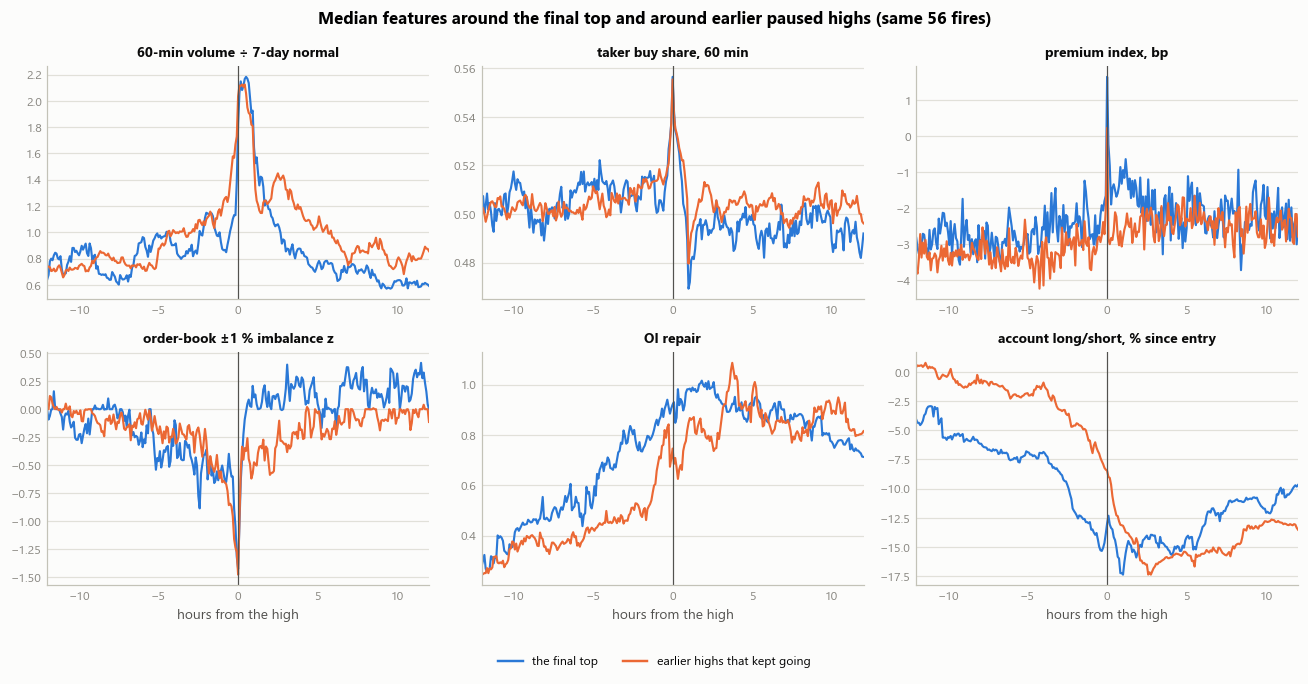

,-240 min,-120 min,-60 min,-30 min,-15 min,0 min
volume_ratio_60,"-0.02 (-0.22, +0.15)","+0.07 (-0.20, +0.29)","-0.20 (-0.46, +0.06)","-0.16 (-0.59, +0.14)","-0.22 (-0.51, +0.19)","-0.20 (-0.51, +0.20)"
taker_buy_share_60,"+0.01 (-0.02, +0.02)","-0.01 (-0.02, +0.01)","-0.01 (-0.03, +0.01)","-0.00 (-0.02, +0.01)","+0.00 (-0.01, +0.02)","+0.00 (-0.00, +0.01)"
premium_bp,"+0.11 (-0.15, +0.98)","+0.60 (+0.01, +1.42)","+0.28 (-0.10, +0.62)","+0.07 (-0.56, +0.43)","+0.12 (-0.87, +0.78)","+0.70 (-0.93, +2.54)"
book_z,"-0.06 (-0.38, +0.32)","-0.10 (-0.65, +0.04)","+0.00 (-0.25, +0.32)","+0.00 (-0.33, +0.43)","+0.00 (-0.47, +0.37)","-0.10 (-0.33, +0.09)"
OR,"+0.42 (+0.09, +0.64)","+0.30 (+0.11, +0.45)","+0.39 (+0.10, +0.58)","+0.42 (+0.06, +0.61)","+0.39 (+0.13, +0.59)","+0.35 (+0.13, +0.61)"
account_lsr_chg_pct,"-6.45 (-9.32, -1.74)","-8.61 (-10.08, -3.89)","-7.07 (-9.50, -3.97)","-5.82 (-10.25, -3.03)","-4.91 (-9.44, -3.54)","-4.99 (-6.94, -3.88)"


In [6]:
T = pd.DataFrame(TVF).T[["fires", "median_at_top", "median_at_false_tops", "median_diff", "ci95_median", "share_top_higher"]]
display(T)
lags_h = np.array(PP["lags_min"]) / 60
show = [("volume_ratio_60", "60-min volume ÷ 7-day normal"), ("taker_buy_share_60", "taker buy share, 60 min"),
        ("premium_bp", "premium index, bp"), ("book_z", "order-book ±1 % imbalance z"),
        ("OR", "OI repair"), ("account_lsr_chg_pct", "account long/short, % since entry")]
fig, axes = plt.subplots(2, 3, figsize=(12, 6.2))
for ax, (col, lab) in zip(axes.flat, show):
    ax.plot(lags_h, PP[col]["top_median"], color=SERIES[0], linewidth=1.4)
    ax.plot(lags_h, PP[col]["false_median"], color=SERIES[1], linewidth=1.4)
    ax.axvline(0, color=INK2, linewidth=0.8); style(ax); ax.set_title(lab, fontsize=9); ax.set_xlim(-12, 12)
for ax in axes[1]:
    ax.set_xlabel("hours from the high")
handles = [Line2D([], [], color=SERIES[0], label="the final top"), Line2D([], [], color=SERIES[1], label="earlier highs that kept going")]
fig.legend(handles=handles, loc="lower center", ncol=2, bbox_to_anchor=(0.5, 0.0))
fig.suptitle("Median features around the final top and around earlier paused highs (same 56 fires)", fontsize=11, fontweight="bold")
plt.tight_layout(rect=(0, 0.06, 1, 1)); plt.show()
pd.DataFrame({col: {lag: f"{v['median_diff']:+.2f} ({v['ci95'][0]:+.2f}, {v['ci95'][1]:+.2f})" for lag, v in PP[col]["at_lags"].items()}
              for col, _ in show}).T.rename(columns=lambda c: f"{c} min")

## 6. Is the top where the flush is repaired?

No. 87 % of tops went past the price the flush started from. The median top sat 2.3 flush-sizes above entry, and
bounce size barely depends on flush size. After price first got back to where the flush started, the next 24 h still
averaged +0.8 %. Open-interest repair does not mark the top either: at the top, a median half of the flushed open
interest was back, with a very wide spread.

,reached,median_first_hours,mean_fwd24_pct,median_fwd24_pct,share_fwd24_negative,median_pct_from_entry,spike_reversal_reached,share_before_top,median_pct_below_top,fires,PR_median,PR_quartiles,share_PR_ge_1,OR_median,OR_quartiles,share_OR_ge_1
PR,105.0,13.35,0.804871,0.402367,0.4,1.466849,99.0,0.909091,-1.798298,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OR,91.0,21.15,0.653693,0.438283,0.384615,1.631153,80.0,0.625,-1.768938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
at_top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,103,2.288018,"[1.6485356221458842, 3.8062144700763576]",0.873786,0.493874,"[-0.28199581317642464, 1.6577744873516098]",0.349515


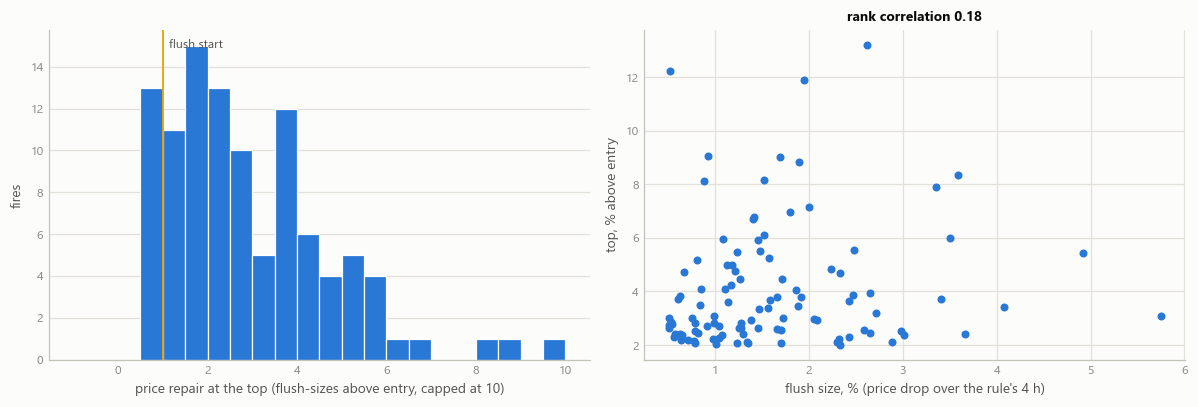

In [7]:
display(pd.DataFrame({k: v for k, v in REP.items() if isinstance(v, dict)}).T)
SH["flush_pct"] = (SH["P0"] / SH["entry"] - 1) * 100
s2 = SH[SH["shape"] == "spike_reversal"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
pr_top = pd.read_csv(RES / "repair_per_fire.csv").dropna(subset=["PR_at_top"])["PR_at_top"]
axes[0].hist(pr_top.clip(upper=10), bins=np.arange(-1, 10.5, 0.5), color=SERIES[0], edgecolor="white", linewidth=0.8)
axes[0].axvline(1, color=SERIES[3], linewidth=1.2)
axes[0].annotate("flush start", xy=(1, axes[0].get_ylim()[1]), xytext=(4, -12), textcoords="offset points", fontsize=8, color=INK2)
axes[0].set_xlabel("price repair at the top (flush-sizes above entry, capped at 10)"); axes[0].set_ylabel("fires"); style(axes[0])
axes[1].scatter(s2["flush_pct"], s2["top_runup_pct"], s=18, color=SERIES[0])
axes[1].set_xlabel("flush size, % (price drop over the rule's 4 h)"); axes[1].set_ylabel("top, % above entry"); style(axes[1], grid_axis="both")
axes[1].set_title(f"rank correlation {s2['flush_pct'].rank().corr(s2['top_runup_pct'].rank()):.2f}", fontsize=9)
plt.tight_layout(); plt.show()

## 7. "Something else that tells it's time": the state map

At every hour of the 7 days after each fire: the move over the next 24 h, by state. The grey line is the bull regime's
own 24 h drift (+0.21 %).
- **Stall.** While the bounce was still making new highs (last new high within an hour), the next 24 h averaged
  +0.51 %. After a day with no new high it averaged +0.12 %.
- **Price repair.** Inside the repair zone (up to 1.5 flush-sizes above entry) the next 24 h averaged +0.35 to +0.48 %.
  Beyond 1.5 it averaged +0.13 %.
- **OI repair.** No pattern.

In both cases the extra is gone, not reversed: the rest of the trade is worth about what any bull-regime hour is worth.

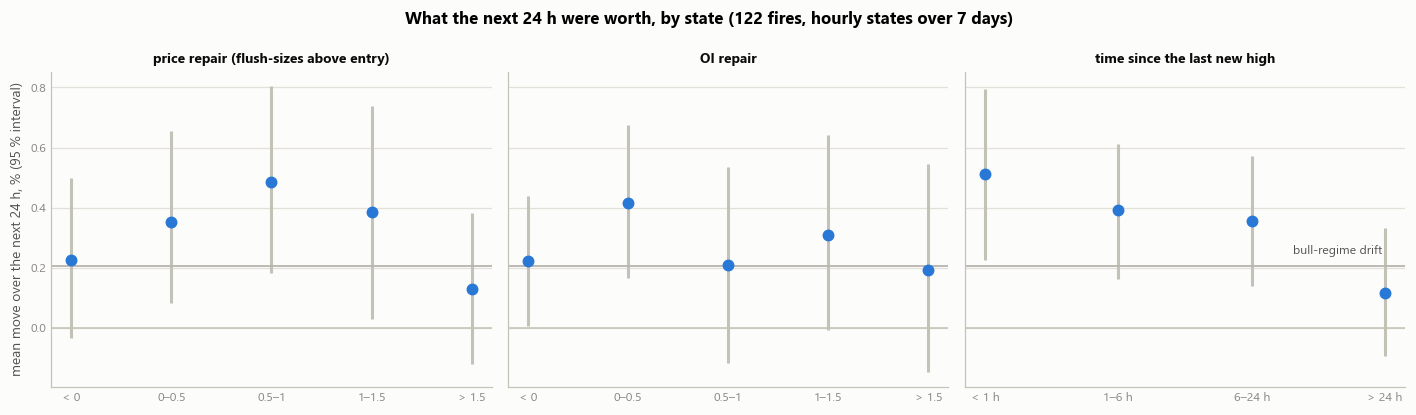

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.8), sharey=True)
labels = {"PR": ["< 0", "0–0.5", "0.5–1", "1–1.5", "> 1.5"], "OR": ["< 0", "0–0.5", "0.5–1", "1–1.5", "> 1.5"],
          "stall_min": ["< 1 h", "1–6 h", "6–24 h", "> 24 h"]}
titles = {"PR": "price repair (flush-sizes above entry)", "OR": "OI repair", "stall_min": "time since the last new high"}
for ax, name in zip(axes, ("PR", "OR", "stall_min")):
    bins = SMAP[name]
    x = np.arange(len(bins))
    m = [b["mean_fwd24_pct"] for b in bins]
    lo = [b["ci95"][0] for b in bins]; hi = [b["ci95"][1] for b in bins]
    ax.vlines(x, lo, hi, color=AXIS, linewidth=2)
    ax.scatter(x, m, s=46, color=SERIES[0], zorder=3)
    ax.axhline(SMAP["bull_regime_drift_24h_pct"], color=NEUTRAL, linewidth=1.2)
    zero_line(ax)
    ax.set_xticks(x); ax.set_xticklabels(labels[name], fontsize=8); style(ax); ax.set_title(titles[name], fontsize=9)
axes[0].set_ylabel("mean move over the next 24 h, % (95 % interval)")
axes[2].annotate("bull-regime drift", xy=(len(SMAP["stall_min"]) - 1, SMAP["bull_regime_drift_24h_pct"]), xytext=(-60, 8),
                 textcoords="offset points", fontsize=8, color=INK2)
fig.suptitle("What the next 24 h were worth, by state (122 fires, hourly states over 7 days)", fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## 8. Data checks, and a production data issue found on the way

The flush-start price matches the ledger exactly, and the archive's open-interest change matches the ledger's
(median difference 0.03 points). But the hourly open interest the live bots read changed meaning on **2026-06-10**, the
day the CoinDesk OI feed died and the Binance fetcher took over. Before, the value stamped at an hour was the open
interest at the end of that hour. Since then it is the open interest at the start of the hour, one bar staler than the
price bar it is joined to. squeeze_bull's live flush test has used that stale value since June, short_squeeze's Asia OI
change too. March–April 2022 match the archive at no lag. Reported only; nothing was changed.

**What it did to the signal.** The sleeve's own flush, cooldown and bull-gate code was run on the hourly snapshot twice:
once with the stored open interest, and once with the value at each bar's close.
- **Since the switch**, the stored series gives two bull fires: 2026-09-04 14:00 and 2026-09-11 17:00.
- **The bar-close series** gives one: 2026-09-04 13:00.
- **SJ-4250**, the trade that started this study, is a fire only because of the stale stamp. Its 4-hour open-interest
  change was −2.48 % on the stored values and −1.79 % at bar closes.

In [9]:
print({k: v for k, v in DC.items() if k != "ledger_oi_timestamp_lag_by_month"})
lag = pd.DataFrame(DC["ledger_oi_timestamp_lag_by_month"]).T
display(lag[["best", "median_rel_diff_best", "stamp_minus_5m", "stamp_plus_55m", "stamp_plus_60m"]].iloc[::3])
import sqb_lib as S
from datetime import datetime, timezone
sm = S.sleeve_math()
with np.load(S.HOURLY) as z:
    hts, hclose, hoi = z["ts"].astype(np.int64), z["close"].astype(float), z["oi_close"].astype(float)
hdays = [datetime.fromtimestamp(int(x), tz=timezone.utc).date() for x in hts]
daily = {}
for d, c in zip(hdays, hclose):
    daily[d] = c
switch = int(datetime(2026, 6, 10, tzinfo=timezone.utc).timestamp())
bar_close_oi = np.where(hts >= switch - 3600, np.r_[hoi[1:], np.nan], hoi)
def bull_fires_since_switch(series):
    vals = [None if not np.isfinite(v) else float(v) for v in series]
    return [datetime.fromtimestamp(int(hts[k]), tz=timezone.utc).strftime("%Y-%m-%d %H:%M")
            for k in sm.kept_flush_indices(vals, hclose.tolist())
            if hts[k] >= switch and sm.classify_regime(sm.backward_only_ret_30d(daily, hdays[k])) == "bull_30d"]
print("bull fires since 2026-06-10 | stored OI (what the bot reads):", bull_fires_since_switch(hoi),
      "| OI at each bar's close (research convention):", bull_fires_since_switch(bar_close_oi))

{'P0_vs_ledger_px_chg_4h_max_abs': 1.5480341215082238e-06, 'entry_vs_path_close_max_rel': 0.0, 'archive_oi_chg_vs_ledger': {'fires_with_archive_oi': 122, 'median_abs_diff': 0.0002833763622077587, 'max_abs_diff': 0.010134153057315808, 'archive_also_le_minus_2pct': 118}}


,best,median_rel_diff_best,stamp_minus_5m,stamp_plus_55m,stamp_plus_60m
2022-01,stamp_plus_55m,0.0,0.002571,0.0,0.000426
2022-04,stamp_minus_5m,0.009286,0.009286,0.00957,0.009698
2022-07,stamp_plus_60m,0.000041,0.004327,0.000647,0.000041
2022-10,stamp_plus_60m,0.000039,0.002932,0.000359,0.000039
2023-01,stamp_plus_60m,0.000039,0.003187,0.000457,0.000039
2023-04,stamp_plus_60m,0.000204,0.003339,0.00083,0.000204
2023-07,stamp_plus_60m,0.000046,0.002789,0.000363,0.000046
2023-10,stamp_plus_60m,0.000056,0.003523,0.000416,0.000056
2024-01,stamp_plus_60m,0.000022,0.003261,0.000475,0.000022
2024-04,stamp_plus_55m,0.000018,0.002908,0.000018,0.000595


bull fires since 2026-06-10 | stored OI (what the bot reads): ['2026-09-04 14:00', '2026-09-11 17:00'] | OI at each bar's close (research convention): ['2026-09-04 13:00']


## Conclusion (exploratory)

- **What happened before the reversal:** a fast push through +2 % to a new high, usually within about 2 hours, with a
  premium pop and a burst of taker buying. That is the same picture as at every earlier high that kept going. At this
  resolution, nothing in real time singles out the final top.
- **The repair levels are not the exit.** Price usually runs well past where the flush started, and bounces are about
  +3 % regardless of the flush's size.
- **What does change is state.** After a day without a new high, or once price is more than 1.5 flush-sizes above
  entry, the next 24 h are worth about the bull regime's drift, no longer the bounce's extra.
- **SJ-4250 would not have been saved** by any of these. It went 56 hours without a new high before its spike, so a
  stall exit would have left even earlier than the time stop. It should not have been a trade at all: it fired only
  because the live open-interest feed has carried each hour's opening value since 2026-06-10.
- **Stage B candidate:** "exit after 24 h without a new high" in place of the fixed 48 h, a time rule tied to the
  bounce's progress rather than to the clock. It would be tested on ETH flushes, BTC non-bull flushes and live fires, if
  the user wants to go on.